# Predictive Analytics for Customer Churn

## Problem
#### Our dataset belongs to a digital streaming platform for movies and TV series. It consists of 21 variables and approximately 245,000 observations. The aim of this problem is to predict customers who will "churn" in advance and assist relevant departments by providing the information of these individuals for preparing necessary action plans

## Columns :

CustomerID: Unique identifier for each customer

SubscriptionType: Type of subscription plan chosen by the customer (e.g., Basic, Premium, Deluxe)

PaymentMethod: Method used for payment (e.g., Credit Card, Electronic Check, PayPal)

PaperlessBilling: Whether the customer uses paperless billing (Yes/No)

ContentType: Type of content accessed by the customer (e.g., Movies, TV Shows, Documentaries)

MultiDeviceAccess: Whether the customer has access on multiple devices (Yes/No)

DeviceRegistered: Device registered by the customer (e.g., Smartphone, Smart TV, Laptop)

GenrePreference: Genre preference of the customer (e.g., Action, Drama, Comedy)

Gender: Gender of the customer (Male/Female)

ParentalControl: Whether parental control is enabled (Yes/No)

SubtitlesEnabled: Whether subtitles are enabled (Yes/No)

AccountAge: Age of the customer's subscription account (in months)

MonthlyCharges: Monthly subscription charges

TotalCharges: Total charges incurred by the customer

ViewingHoursPerWeek: Average number of viewing hours per week

SupportTicketsPerMonth: Number of customer support tickets raised per month

AverageViewingDuration: Average duration of each viewing session

ContentDownloadsPerMonth: Number of content downloads per month

UserRating: Customer satisfaction rating (1 to 5)

WatchlistSize: Size of the customer's content watchlist

Churn: Situation of customer churn or not (target variable)

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold,RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score

In [27]:
df=pd.read_csv("CustomerChurn_dataset.csv")
df.head()

,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,...,ContentDownloadsPerMonth,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn
0,20,11.055215,221.104302,Premium,Mailed check,No,Both,No,Mobile,36.758104,...,10,Sci-Fi,2.176498,4,Male,3,No,No,CB6SXPNVZA,0
1,57,5.175208,294.986882,Basic,Credit card,Yes,Movies,No,Tablet,32.450568,...,18,Action,3.478632,8,Male,23,No,Yes,S7R2G87O09,0
2,73,12.106657,883.785952,Basic,Mailed check,Yes,Movies,No,Computer,7.395160,...,23,Fantasy,4.238824,6,Male,1,Yes,Yes,EASDC20BDT,0
3,32,7.263743,232.439774,Basic,Electronic check,No,TV Shows,No,Tablet,27.960389,...,30,Drama,4.276013,2,Male,24,Yes,Yes,NPF69NT69N,0
4,57,16.953078,966.325422,Premium,Electronic check,Yes,TV Shows,No,TV,20.083397,...,20,Comedy,3.616170,4,Female,0,No,No,4LGYPK7VOL,0


In [28]:
def show_info(dataframe):
    print("***** NAN *****")
    print(dataframe.isnull().sum())
    print("***** Duplicated *****")
    print(dataframe.duplicated().sum())
    print("***** NUNIQUE *****")
    print(dataframe.nunique())
    print("***** INFO *****")
    print(dataframe.info())
    print("***** COLUMNS *****")
    print(dataframe.columns)
    print("***** DESCRIPTIVE STATISTICS *****")
    print(dataframe.describe().T)

print(show_info(df))

***** NAN *****
AccountAge                  0
MonthlyCharges              0
TotalCharges                0
SubscriptionType            0
PaymentMethod               0
PaperlessBilling            0
ContentType                 0
MultiDeviceAccess           0
DeviceRegistered            0
ViewingHoursPerWeek         0
AverageViewingDuration      0
ContentDownloadsPerMonth    0
GenrePreference             0
UserRating                  0
SupportTicketsPerMonth      0
Gender                      0
WatchlistSize               0
ParentalControl             0
SubtitlesEnabled            0
CustomerID                  0
Churn                       0
dtype: int64
***** Duplicated *****
0
***** NUNIQUE *****
AccountAge                     119
MonthlyCharges              243787
TotalCharges                243787
SubscriptionType                 3
PaymentMethod                    4
PaperlessBilling                 2
ContentType                      3
MultiDeviceAccess                2
DeviceRegistered

In [29]:
# Grab Variables
def grab_variable(dataframe, num_th=10, car_th=20, var_name=False):
    
    # Categoric Variables #
    
    cat_var = [i for i in dataframe.columns if dataframe[i].dtypes in ["object", "category", "bool"]]
    
    num_but_cat = [i for i in dataframe.columns if dataframe[i].dtypes in ["int64", "float64"]
                   and dataframe[i].nunique() <= num_th]
    
    cat_but_car = [i for i in dataframe.columns if dataframe[i].dtypes in ["category", "object"]
                   and dataframe[i].nunique() > car_th]
    
    cat_var = cat_var + num_but_cat
    cat_var = [i for i in cat_var if i not in cat_but_car]

    # Numeric Variables #
    num_var = [i for i in dataframe.columns if dataframe[i].dtypes in ["int64", "float64"]
               and dataframe[i].nunique() > num_th]

    print("Observation:", len(dataframe))
    print("Number of Variables:", len(dataframe.columns))
    print("Number of Categoric Variables:", len(cat_var))
    print("Number of Num but Cat Variables:", len(num_but_cat))
    print("Number of Cat but Cardinal Variables:", len(cat_but_car))
    print("Number of Numeric Variables:", len(num_var))

    if var_name:
        print("Categoric Variables:", cat_var)
        print("Numeric But Categoric Variables:", num_but_cat)
        print("Categoric But Cardinal Variables:", cat_but_car)
        print("Numeric Variables:", num_var)
    return cat_var, cat_but_car, num_var

cat_var, cat_but_car, num_var = grab_variable(df)

Observation: 243787
Number of Variables: 21
Number of Categoric Variables: 12
Number of Num but Cat Variables: 2
Number of Cat but Cardinal Variables: 1
Number of Numeric Variables: 8


In [30]:
#Dropping the customerID column as it is not useful for prediction
df.drop("CustomerID",axis=1,inplace=True)

#Dropping the SupportTicketsPerMonth column as it has missing values and is not useful for prediction
df.drop("SupportTicketsPerMonth",axis=1,inplace=True)

In [ ]:
#converting the categorical variables into numerical variables using one hot encoding

encoder=LabelEncoder()
cat_var=["SubscriptionType","PaymentMethod","PaperlessBilling","ContentType","MultiDeviceAccess","DeviceRegistered","GenrePreference","Gender","SubtitlesEnabled","ParentalControl"]
for col in cat_var:
    df[col]=encoder.fit_transform(df[col])


df.head()

,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,AverageViewingDuration,ContentDownloadsPerMonth,GenrePreference,UserRating,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,Churn
0,20,11.055215,221.104302,1,3,0,0,0,1,36.758104,63.531377,10,4,2.176498,1,3,0,0,0
1,57,5.175208,294.986882,0,1,1,1,0,3,32.450568,25.725595,18,0,3.478632,1,23,0,1,0
2,73,12.106657,883.785952,0,3,1,1,0,0,7.395160,57.364061,23,3,4.238824,1,1,1,1,0
3,32,7.263743,232.439774,0,2,0,2,0,3,27.960389,131.537507,30,2,4.276013,1,24,1,1,0
4,57,16.953078,966.325422,1,2,1,2,0,2,20.083397,45.356653,20,1,3.616170,0,0,0,0,0


In [32]:
#dividing the data into features and target
X=df.drop("Churn",axis=1)
y=df["Churn"]   
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [33]:
# defining the model with multi_class as ovr
logistic=LogisticRegression()
logistic.fit(X_train,y_train)

c:\Users\123456\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [34]:
y_pred=logistic.predict(X_test)
model_prob=logistic.predict_proba(X_test)


In [35]:
print(classification_report(y_test,y_pred) )

              precision    recall  f1-score   support

           0       0.83      0.98      0.90     59923
           1       0.56      0.09      0.16     13214

    accuracy                           0.82     73137
   macro avg       0.70      0.54      0.53     73137
weighted avg       0.78      0.82      0.77     73137



In [36]:
print(confusion_matrix(y_test,y_pred))

[[58947   976]
 [11965  1249]]


In [37]:
model_prob

array([[0.9220199 , 0.0779801 ],
       [0.39385885, 0.60614115],
       [0.85234591, 0.14765409],
       ...,
       [0.85483289, 0.14516711],
       [0.92095603, 0.07904397],
       [0.86848258, 0.13151742]], shape=(73137, 2))

In [38]:
model_prob=model_prob[:,1]

In [41]:
df_model_auc=roc_auc_score(y_test,model_prob)
df_model_auc

0.7415114646107529

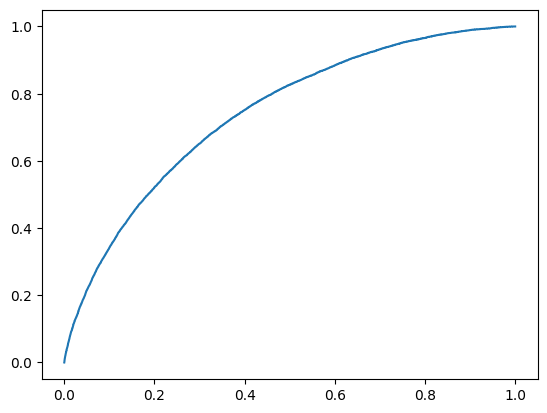

In [47]:
from matplotlib import pyplot
from sklearn.metrics import roc_curve

model_fpr, model_tpr, model_thresholds = roc_curve(y_test, model_prob)
pyplot.plot(model_fpr, model_tpr)  
pyplot.show()